In [1]:
from collections import Counter, defaultdict
from matplotlib.lines import Line2D
from scipy.spatial import distance
import matplotlib.pyplot as plt
from rdkit import Chem
import numpy as np
import pandas as pd
from tqdm import tqdm
import pickle
import os
import tarfile

import pymol
from pymol import cmd
import matplotlib.image as mpimg
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen
from rdkit.Chem.QED import qed
import matplotlib.patches as patches
from pycirclize import Circos
from itertools import combinations
from matplotlib.colors import to_hex
import numpy as np
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import stylia

# Format: print | Style: article — change with stylia.set_format() / stylia.set_style()
stylia.set_format("print")
stylia.set_style("article")

In [2]:
# Define some paths
root = '../../../github/mtb-targeted-protein-degradation/notebooks'

LIBRARY = 'Enamine-DL-HLL-100'  # Enamine-DL-HLL-100 or EnamineREAL10B
LIBRARY = 'EnamineREAL10B'

if LIBRARY == "Enamine-DL-HLL-100":
    ID_TO_SMILES = pickle.load(open(os.path.join(root, "..", "output", "enamine_characterization", "ID_TO_SMI.pkl"), "rb"))
    DOCKING_RESULTS = {}
    PATH_TO_DOCKING_RESULTS = os.path.join(root, "..", "output", "unidock_docking", 'docking_results')
    for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS))):
        scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS, pocket, 'report.csv'))
        DOCKING_RESULTS[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

elif LIBRARY == "EnamineREAL10B":
    ID_TO_SMILES = pd.read_csv(os.path.join(root, "..", "output", "unidock_REAL_docking", 'inference_10B', 'clustered_compounds.csv'))
    ID_TO_SMILES = {i: j for i,j in zip(ID_TO_SMILES['id'], ID_TO_SMILES['smiles'])}
    DOCKING_RESULTS = {}
    PATH_TO_DOCKING_RESULTS = os.path.join(root, "..", "output", "unidock_REAL_docking_2", 'docking_results')
    for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS))):
        scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS, pocket, 'report.csv'))
        assert len(scores) == 99105
        DOCKING_RESULTS[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}


# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "output", "pocket_detection_data.csv"))
pocket_detection_data_interpro = pd.read_csv(os.path.join(root, "..", "output", "pocket_detection_data_interpro.tsv"), sep='\t')

# Uniprot to gene name
uniprot_to_gene = pd.read_csv(os.path.join(root, "..", "data", "mtb_trna_synthetases_bosch_2021_fig5.csv"))
uniprot_to_gene = {i: j for i,j in zip(uniprot_to_gene['uniprot_ac'], uniprot_to_gene['gene_name_in_bosch_2021'])}

# Define pockets, compounds and proteins
POCKETS = sorted(DOCKING_RESULTS)
COMPOUNDS = sorted(DOCKING_RESULTS[POCKETS[0]])
PROTEINS = sorted(set([i.split("_")[1] for i in POCKETS]))
print(f"Number of pockets: {len(POCKETS)}")
print(f"Number of compounds: {len(COMPOUNDS)}")
print(f"Number of proteins: {len(PROTEINS)}")

100%|██████████| 276/276 [00:17<00:00, 15.81it/s]

Number of pockets: 276
Number of compounds: 99105
Number of proteins: 21


In [3]:
# Map protein to min docking score for a given compound
protein_to_cpds = dict()
for protein in tqdm(PROTEINS):
    protein_to_cpds[protein] = dict()
    pockets = sorted([p for p in POCKETS if p.split("_")[1] == protein])
    for compound in COMPOUNDS:
        scores = [DOCKING_RESULTS[p][compound] for p in pockets]
        protein_to_cpds[protein][compound] = min(scores)

n_prots = 4
score_cutoff = -11
SELECTED_COMPOUNDS = [cpd for cpd in COMPOUNDS if len([protein for protein in PROTEINS if protein_to_cpds[protein][cpd] < score_cutoff]) > n_prots]
print(f"Number of selected compounds: {len(SELECTED_COMPOUNDS)}")

100%|██████████| 21/21 [00:08<00:00,  2.35it/s]


Number of selected compounds: 162


In [4]:
df = []
for cpd in tqdm(SELECTED_COMPOUNDS):

    # Properties
    smiles = ID_TO_SMILES[cpd]
    mol = Chem.MolFromSmiles(smiles)
    mw = round(Descriptors.MolWt(mol), 3)
    logp = round(Crippen.MolLogP(mol), 3)
    qed_score = round(qed(mol), 3)

    # Ranks
    ranks = []
    for pocket in POCKETS:
        values = [DOCKING_RESULTS[pocket][cpd] for cpd in DOCKING_RESULTS[pocket]]
        value = DOCKING_RESULTS[pocket][cpd]
        # values = [protein_to_cpds[protein][cpd] for protein in protein_to_cpds]
        # value = protein_to_cpds[protein][cpd]
        ranks.append(sum([i < value for i in values]))
    avg_rank = int(np.mean(ranks))
    std_rank = int(np.std(ranks))
    perc_10 = int(np.percentile(ranks, 10))
    perc_50 = int(np.percentile(ranks, 50))
    perc_90 = int(np.percentile(ranks, 90))

    # Minimum docking scores
    scores = []
    for protein in PROTEINS:
        scores.append(protein_to_cpds[protein][cpd])
    

    df.append([LIBRARY, cpd, smiles, mw, logp, qed_score, avg_rank, std_rank, perc_10, perc_50, perc_90] + scores)
df = pd.DataFrame(df, columns=['library', 'compound_id', 'smiles', 'mw', 'logp', 'qed', 'avgrank', 'stdrank', 'rank_01', 'rank_05', 'rank_09'] + 
                  [uniprot_to_gene[i] for i in PROTEINS])
df = df[df.columns[:11].tolist() + sorted(df.columns[11:])]

  0%|          | 0/162 [00:00<?, ?it/s]

100%|██████████| 162/162 [06:33<00:00,  2.43s/it]


In [5]:
TIER_1 = ['pheS', 'aspS', 'lysS', 'ileS']
TIER_2 = ["valS", "alaS", "leuS", "tyrS", "trpS", "serS"]

In [ ]:
TARGETS_8, TARGETS_9, TARGETS_10, TARGETS_11, TARGETS_12 = [], [], [], [], []

for scores in df[df.columns[11:]].values:
    TARGETS_8.append(sum([1 for i in scores if i < -8]))
    TARGETS_9.append(sum([1 for i in scores if i < -9]))
    TARGETS_10.append(sum([1 for i in scores if i < -10]))
    TARGETS_11.append(sum([1 for i in scores if i < -11]))
    TARGETS_12.append(sum([1 for i in scores if i < -12]))

df['targets_12'] = TARGETS_12
df['targets_11'] = TARGETS_11
df['targets_10'] = TARGETS_10
df['targets_9'] = TARGETS_9
df['targets_8'] = TARGETS_8
df['avg_score_tier1'] = [np.average(i) for i in df[TIER_1].values]
df = df.sort_values('avg_score_tier1').reset_index(drop=True)

# Save results
PATH_TO_OUTPUT = os.path.join(PATH_TO_DOCKING_RESULT "..", "deliverable")
os.makedirs(PATH_TO_OUTPUT, exist_ok=True)
df.to_csv(os.path.join(PATH_TO_OUTPUT, f"compounds_{LIBRARY}.csv"), index=False)

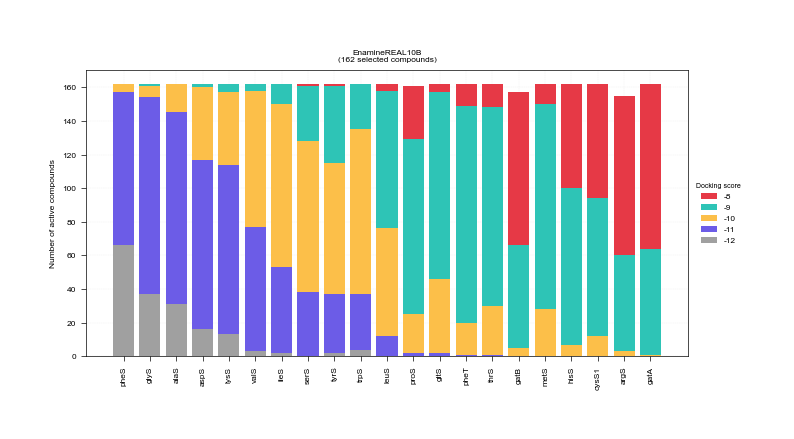

In [9]:
GENES = np.array([uniprot_to_gene[i] for i in PROTEINS])
SCORES = [-12, -11, -10, -9, -8]
pal = stylia.CategoricalPalette("npg")
COLORS = pal.get(len(SCORES))

targets = []
for gene in GENES:
    t = []
    for score in SCORES:
        t.append(len(df[df[gene] < score]))
    targets.append(t)
targets = np.array(targets)
indices = np.argsort(targets[:, 1])[::-1]
targets = targets[indices]
GENES = GENES[indices]

fig, axs = stylia.create_figure(1, 1)
ax = axs.next()
ax.grid(linestyle='--', zorder=-2)
ax.set_xticks([i for i in range(len(GENES))])
ax.set_xticklabels([i for i in GENES], rotation=90)
for x, target in enumerate(targets):
    for c, t in enumerate(target[::-1]):
        if x != 0:
            ax.bar(x, t, edgecolor='k', color=COLORS[c], zorder=2)
        else:
            ax.bar(x, t, edgecolor='k', color=COLORS[c], zorder=2, label=SCORES[::-1][c])

stylia.label(ax, xlabel="", ylabel="Number of active compounds", title=f"{LIBRARY}\n({len(df)} selected compounds)")
ax.legend(title='Docking score', ncol=1, loc="center left", bbox_to_anchor=(1.0, 0.5))

stylia.save_figure(os.path.join(PATH_TO_OUTPUT, f"proteins_{LIBRARY}.png"))

targets = pd.DataFrame(targets, columns=["score_12", "score_11", "score_10", "score_9", 'score_8'])
targets['gene_name'] = GENES
targets = targets[['gene_name', "score_12", "score_11", "score_10", "score_9"]]
targets.to_csv(os.path.join(PATH_TO_OUTPUT, f"proteins_{LIBRARY}.csv"), index=False)

In [11]:
PATH_TO_OUTPUT

'../../../github/mtb-targeted-protein-degradation/notebooks/../output/unidock_REAL_docking_2/docking_results/../deliverable'